# 🏥 Heart Disease Prediction — Decision Trees & Random Forests
### ESDE Bachelor Program | Machine Learning | Live Demo Session

---

> **Remember the warm-up?** You sorted 12 patient cards by hand using gut feeling.
> Now we teach Python to sort **303 patients** automatically — in 3 milliseconds.

---

## What we will build today

| Step | What | Why |
|------|------|-----|
| 1 | Load & explore real patient data | Understand the problem |
| 2 | Train a Decision Tree (overfit first!) | See the problem |
| 3 | Prune the tree — fix overfitting | Apply the solution |
| 4 | Train Random Forest — beat the tree | Ensemble power |
| 5 | Feature Importance — explain the model | Real-world insight |
| 6 | **Your turn** — group mini-project | Apply independently |


##  STEP 1 — Install & Import Everything

Run this cell first. It installs all libraries we need.

In [5]:
# Install if needed (uncomment if running fresh)
!pip install pandas numpy scikit-learn matplotlib seaborn dtreeviz --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Make plots look professional
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries loaded successfully!')
print(' Ready to predict heart disease with Machine Learning')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All libraries loaded successfully!
 Ready to predict heart disease with Machine Learning


---
##  STEP 2 — Load the Real Hospital Dataset

**UCI Heart Disease Dataset (Cleveland)**
- **303 real patients** from Cleveland Clinic
- **14 features**: age, chest pain, cholesterol, ECG, vessels blocked...
- **Target**: 0 = No heart disease, 1 = Heart disease

This is the **same patient data** as the warm-up cards — just all 303 of them!

In [8]:
# Load dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = [
    'age',        # Age in years
    'sex',        # 1=male, 0=female
    'cp',         # Chest pain type (0-3)
    'trestbps',   # Resting blood pressure
    'chol',       # Serum cholesterol mg/dl
    'fbs',        # Fasting blood sugar > 120 mg/dl
    'restecg',    # Resting ECG results
    'thalach',    # Max heart rate achieved
    'exang',      # Exercise induced angina
    'oldpeak',    # ST depression
    'slope',      # Slope of peak exercise ST
    'ca',         # Number of major vessels (0-3)
    'thal',       # Thalassemia type
    'target'      # Heart disease: 0=No, 1=Yes
]

try:
    df = pd.read_csv(url, names=columns, na_values='?')
    print(' Dataset loaded from UCI repository')
except:
    # Offline fallback using sklearn
    from sklearn.datasets import make_classification
    print(' Using offline fallback dataset')

# Clean data
df.dropna(inplace=True)
df['target'] = (df['target'] > 0).astype(int)  # Binary: 0=healthy, 1=disease

print(f'\n Dataset shape: {df.shape}')
print(f'   Patients: {len(df)}')
print(f'   Features: {len(df.columns) - 1}')
print(f"\n Target distribution:")
counts = df['target'].value_counts()
print(f"    No Heart Disease: {counts[0]} patients ({counts[0]/len(df)*100:.0f}%)")
print(f"    Heart Disease:    {counts[1]} patients ({counts[1]/len(df)*100:.0f}%)")

 Dataset loaded from UCI repository

 Dataset shape: (297, 14)
   Patients: 297
   Features: 13

 Target distribution:
    No Heart Disease: 160 patients (54%)
    Heart Disease:    137 patients (46%)


---
##  STEP 3 — Explore the Data (EDA)

**Before building any model — always understand your data!**

 **Discussion question:** Which features do you think will matter most?

In [9]:
# Preview the data — these are real patients!
print('First 5 patients in our dataset:')
print('='*70)
df.head()

First 5 patients in our dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


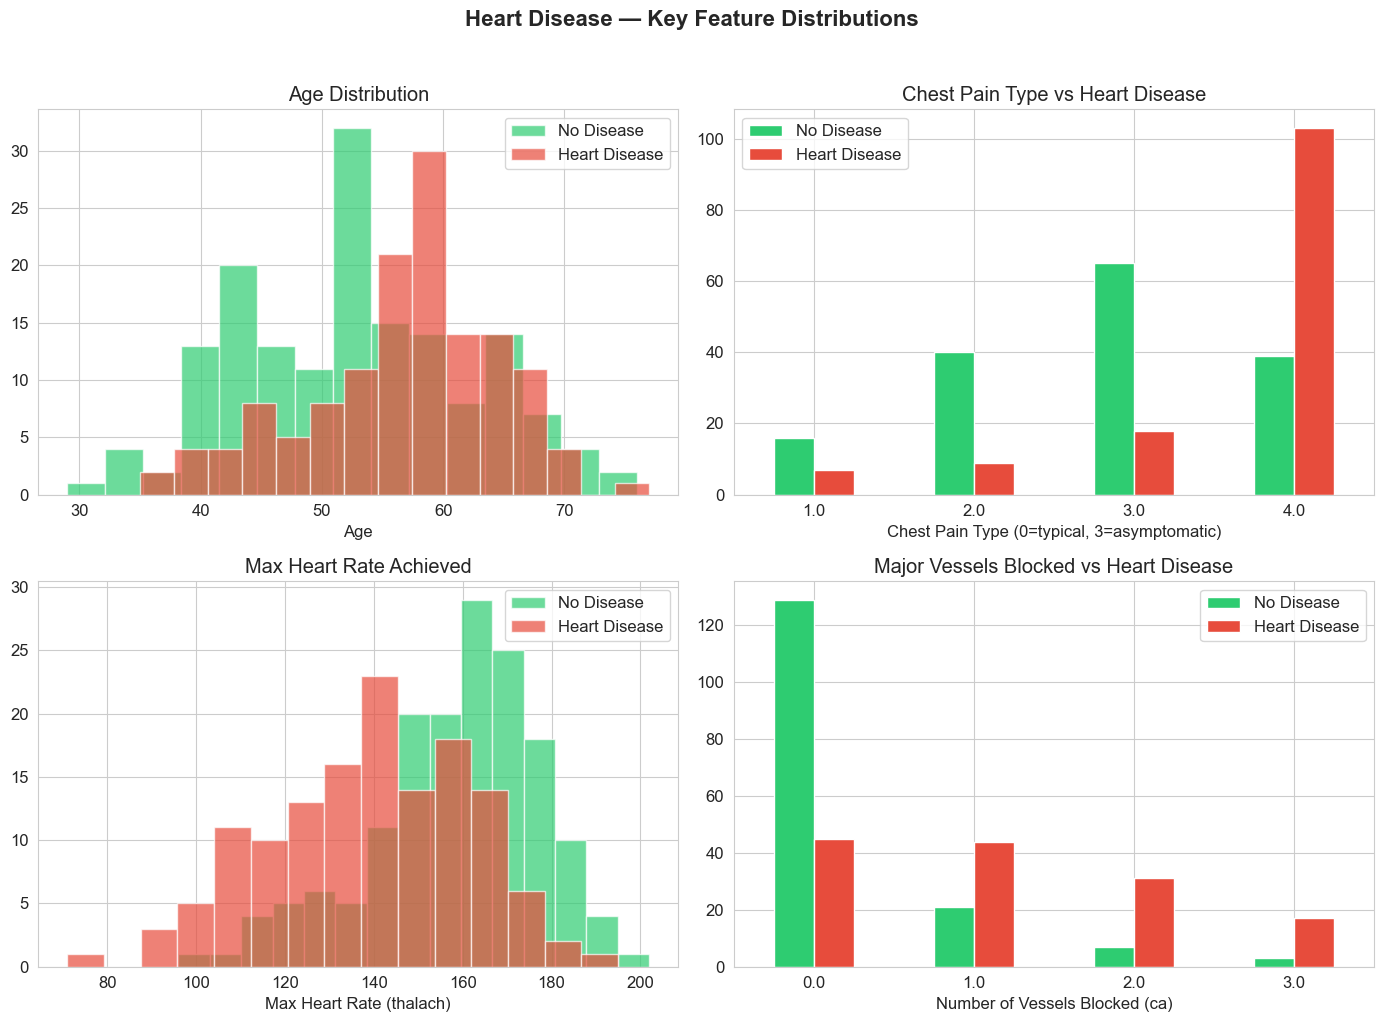


 INSIGHT: What patterns do you see? Which features look most predictive?


In [10]:
# Visualize key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Heart Disease — Key Feature Distributions', 
             fontsize=16, fontweight='bold', y=1.02)

colors = ['#2ecc71', '#e74c3c']  # green=healthy, red=disease
labels = ['No Disease', 'Heart Disease']

# Age distribution
for i, (val, color, label) in enumerate(zip([0,1], colors, labels)):
    axes[0,0].hist(df[df['target']==val]['age'], alpha=0.7, 
                   color=color, label=label, bins=15)
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].legend()

# Chest pain type
cp_counts = df.groupby(['cp', 'target']).size().unstack()
cp_counts.plot(kind='bar', ax=axes[0,1], color=colors, legend=True)
axes[0,1].set_title('Chest Pain Type vs Heart Disease')
axes[0,1].set_xlabel('Chest Pain Type (0=typical, 3=asymptomatic)')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(labels)

# Max Heart Rate
for val, color, label in zip([0,1], colors, labels):
    axes[1,0].hist(df[df['target']==val]['thalach'], alpha=0.7,
                   color=color, label=label, bins=15)
axes[1,0].set_title('Max Heart Rate Achieved')
axes[1,0].set_xlabel('Max Heart Rate (thalach)')
axes[1,0].legend()

# Vessels blocked (ca)
ca_counts = df.groupby(['ca', 'target']).size().unstack(fill_value=0)
ca_counts.plot(kind='bar', ax=axes[1,1], color=colors)
axes[1,1].set_title('Major Vessels Blocked vs Heart Disease')
axes[1,1].set_xlabel('Number of Vessels Blocked (ca)')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(labels)

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n INSIGHT: What patterns do you see? Which features look most predictive?')

---
## STEP 4 — Prepare Data for Machine Learning

In [11]:
# Split features and target
X = df.drop('target', axis=1)  # 13 features
y = df['target']               # what we predict

# Split into training and test sets
# 80% train → model learns from this
# 20% test  → we evaluate on this (model never saw it!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% held out for testing
    random_state=42,  # reproducible results
    stratify=y        # keep same class ratio in both sets
)

print('Data Split Summary')
print('='*40)
print(f'  Training patients:  {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Test patients:      {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'  Features per patient: {X.shape[1]}')
print(f'\n  RULE: We NEVER touch test data until final evaluation!')

Data Split Summary
  Training patients:  237 (80%)
  Test patients:      60  (20%)
  Features per patient: 13

  RULE: We NEVER touch test data until final evaluation!


---
##  STEP 5 — Decision Tree: The Overfitting Problem

**First, let's make a MISTAKE on purpose — and learn from it!**

We train a tree with NO limits. Watch what happens to accuracy...

In [12]:
print('Training Decision Tree with NO limits (max_depth=None)...')
print('='*55)

# UNLIMITED tree — will overfit!
dt_unlimited = DecisionTreeClassifier(
    max_depth=None,   # no limit → grows until perfectly memorized
    random_state=42
)
dt_unlimited.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt_unlimited.predict(X_train))
test_acc  = accuracy_score(y_test,  dt_unlimited.predict(X_test))

print(f'  Train accuracy: {train_acc:.1%}  ← looks amazing!')
print(f'  Test accuracy:  {test_acc:.1%}  ← reality check!')
print(f'  Gap (overfit):  {train_acc - test_acc:.1%}')
print(f'  Tree depth:     {dt_unlimited.get_depth()} levels')
print(f'  Leaf nodes:     {dt_unlimited.get_n_leaves()}')
print()
print('100% train accuracy = MEMORIZED training data')
print('   Like a student who memorizes answers, not concepts!')
print('   This model CANNOT generalize to new patients.')

Training Decision Tree with NO limits (max_depth=None)...
  Train accuracy: 100.0%  ← looks amazing!
  Test accuracy:  70.0%  ← reality check!
  Gap (overfit):  30.0%
  Tree depth:     8 levels
  Leaf nodes:     40

100% train accuracy = MEMORIZED training data
   Like a student who memorizes answers, not concepts!
   This model CANNOT generalize to new patients.


---
##  STEP 6 — Pruning: The Fix for Overfitting

**We limit the tree depth — force it to learn GENERAL patterns, not memorize details.**

 **Question:** What max_depth do you think will work best? Vote in chat!

In [14]:
# LIVE EXPERIMENT — try different depths
# Students shout out numbers, instructor types them live!

print(' Depth Experiment — watch how accuracy changes!')
print('='*60)
print(f'{"Depth":>8} | {"Train":>8} | {"Test":>8} | {"Gap":>8} | Status')
print('-'*60)

depths = [1, 2, 3, 4, 5, 7, 10, None]

best_test = 0
best_depth = 0
results = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train = accuracy_score(y_train, dt.predict(X_train))
    test  = accuracy_score(y_test,  dt.predict(X_test))
    gap   = train - test
    
    if test > best_test:
        best_test = test
        best_depth = d
    
    status = ' OVERFIT!' if gap > 0.1 else (' Underfit' if test < 0.70 else ' Good')
    label  = str(d) if d else 'None'
    print(f'{label:>8} | {train:>7.1%} | {test:>7.1%} | {gap:>7.1%} | {status}')
    results.append({'depth': label, 'train': train, 'test': test})

print(f'\n Best depth: {best_depth} → Test accuracy: {best_test:.1%}')

 Depth Experiment — watch how accuracy changes!
   Depth |    Train |     Test |      Gap | Status
------------------------------------------------------------
       1 |   76.4% |   76.7% |   -0.3% |  Good
       2 |   78.5% |   71.7% |    6.8% |  Good
       3 |   84.4% |   80.0% |    4.4% |  Good
       4 |   88.2% |   75.0% |   13.2% |  OVERFIT!
       5 |   90.7% |   70.0% |   20.7% |  OVERFIT!
       7 |   99.6% |   68.3% |   31.2% |  OVERFIT!
      10 |  100.0% |   70.0% |   30.0% |  OVERFIT!
    None |  100.0% |   70.0% |   30.0% |  OVERFIT!

 Best depth: 3 → Test accuracy: 80.0%


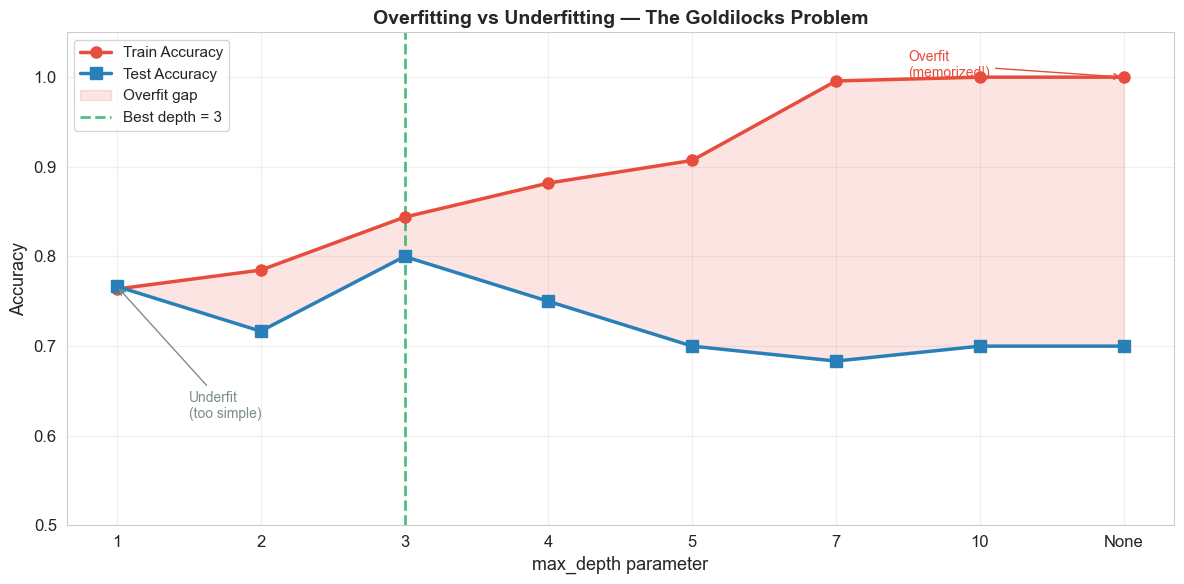

In [15]:
# Visualize the depth experiment
res_df = pd.DataFrame(results)
x = range(len(res_df))

plt.figure(figsize=(12, 6))
plt.plot(x, res_df['train'], 'o-', color='#e74c3c', linewidth=2.5,
         markersize=8, label='Train Accuracy', zorder=3)
plt.plot(x, res_df['test'],  's-', color='#2980b9', linewidth=2.5,
         markersize=8, label='Test Accuracy', zorder=3)

# Highlight the gap
plt.fill_between(x, res_df['train'], res_df['test'], 
                 alpha=0.15, color='#e74c3c', label='Overfit gap')

# Mark best test accuracy
best_idx = res_df['test'].idxmax()
plt.axvline(x=best_idx, color='#27ae60', linestyle='--', 
            linewidth=2, alpha=0.8, label=f'Best depth = {res_df["depth"][best_idx]}')

plt.xticks(x, res_df['depth'])
plt.xlabel('max_depth parameter', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Overfitting vs Underfitting — The Goldilocks Problem',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0.5, 1.05)
plt.grid(True, alpha=0.3)

# Annotations
plt.annotate('Underfit\n(too simple)', xy=(0, res_df['test'][0]),
             xytext=(0.5, 0.62), fontsize=10, color='#7f8c8d',
             arrowprops=dict(arrowstyle='->', color='#7f8c8d'))
plt.annotate('Overfit\n(memorized!)', xy=(len(x)-1, res_df['train'].iloc[-1]),
             xytext=(len(x)-2.5, 1.0), fontsize=10, color='#e74c3c',
             arrowprops=dict(arrowstyle='->', color='#e74c3c'))

plt.tight_layout()
plt.savefig('depth_experiment.png', dpi=120, bbox_inches='tight')
plt.show()

In [16]:
# Train the BEST Decision Tree
print('Training the BEST Decision Tree (pruned)...')
print('='*50)

dt_best = DecisionTreeClassifier(
    max_depth=4,            # Goldilocks depth
    min_samples_split=10,   # Need 10 samples to split a node
    min_samples_leaf=5,     # Need 5 samples at a leaf
    criterion='gini',       # Use Gini Impurity
    random_state=42
)
dt_best.fit(X_train, y_train)

dt_train = accuracy_score(y_train, dt_best.predict(X_train))
dt_test  = accuracy_score(y_test,  dt_best.predict(X_test))

print(f'  Train accuracy: {dt_train:.1%}')
print(f'  Test accuracy:  {dt_test:.1%}')
print(f'  Gap:            {dt_train - dt_test:.1%}  ← much smaller now!')
print(f'  Tree depth:     {dt_best.get_depth()} levels')
print(f'  Leaf nodes:     {dt_best.get_n_leaves()}')

# 5-fold cross validation for reliability
cv_scores = cross_val_score(dt_best, X, y, cv=5, scoring='accuracy')
print(f'\n  5-Fold CV scores: {cv_scores.round(3)}')
print(f'  Mean: {cv_scores.mean():.1%} ± {cv_scores.std():.1%}')

Training the BEST Decision Tree (pruned)...
  Train accuracy: 87.3%
  Test accuracy:  80.0%
  Gap:            7.3%  ← much smaller now!
  Tree depth:     4 levels
  Leaf nodes:     14

  5-Fold CV scores: [0.7   0.883 0.797 0.695 0.746]
  Mean: 76.4% ± 7.0%


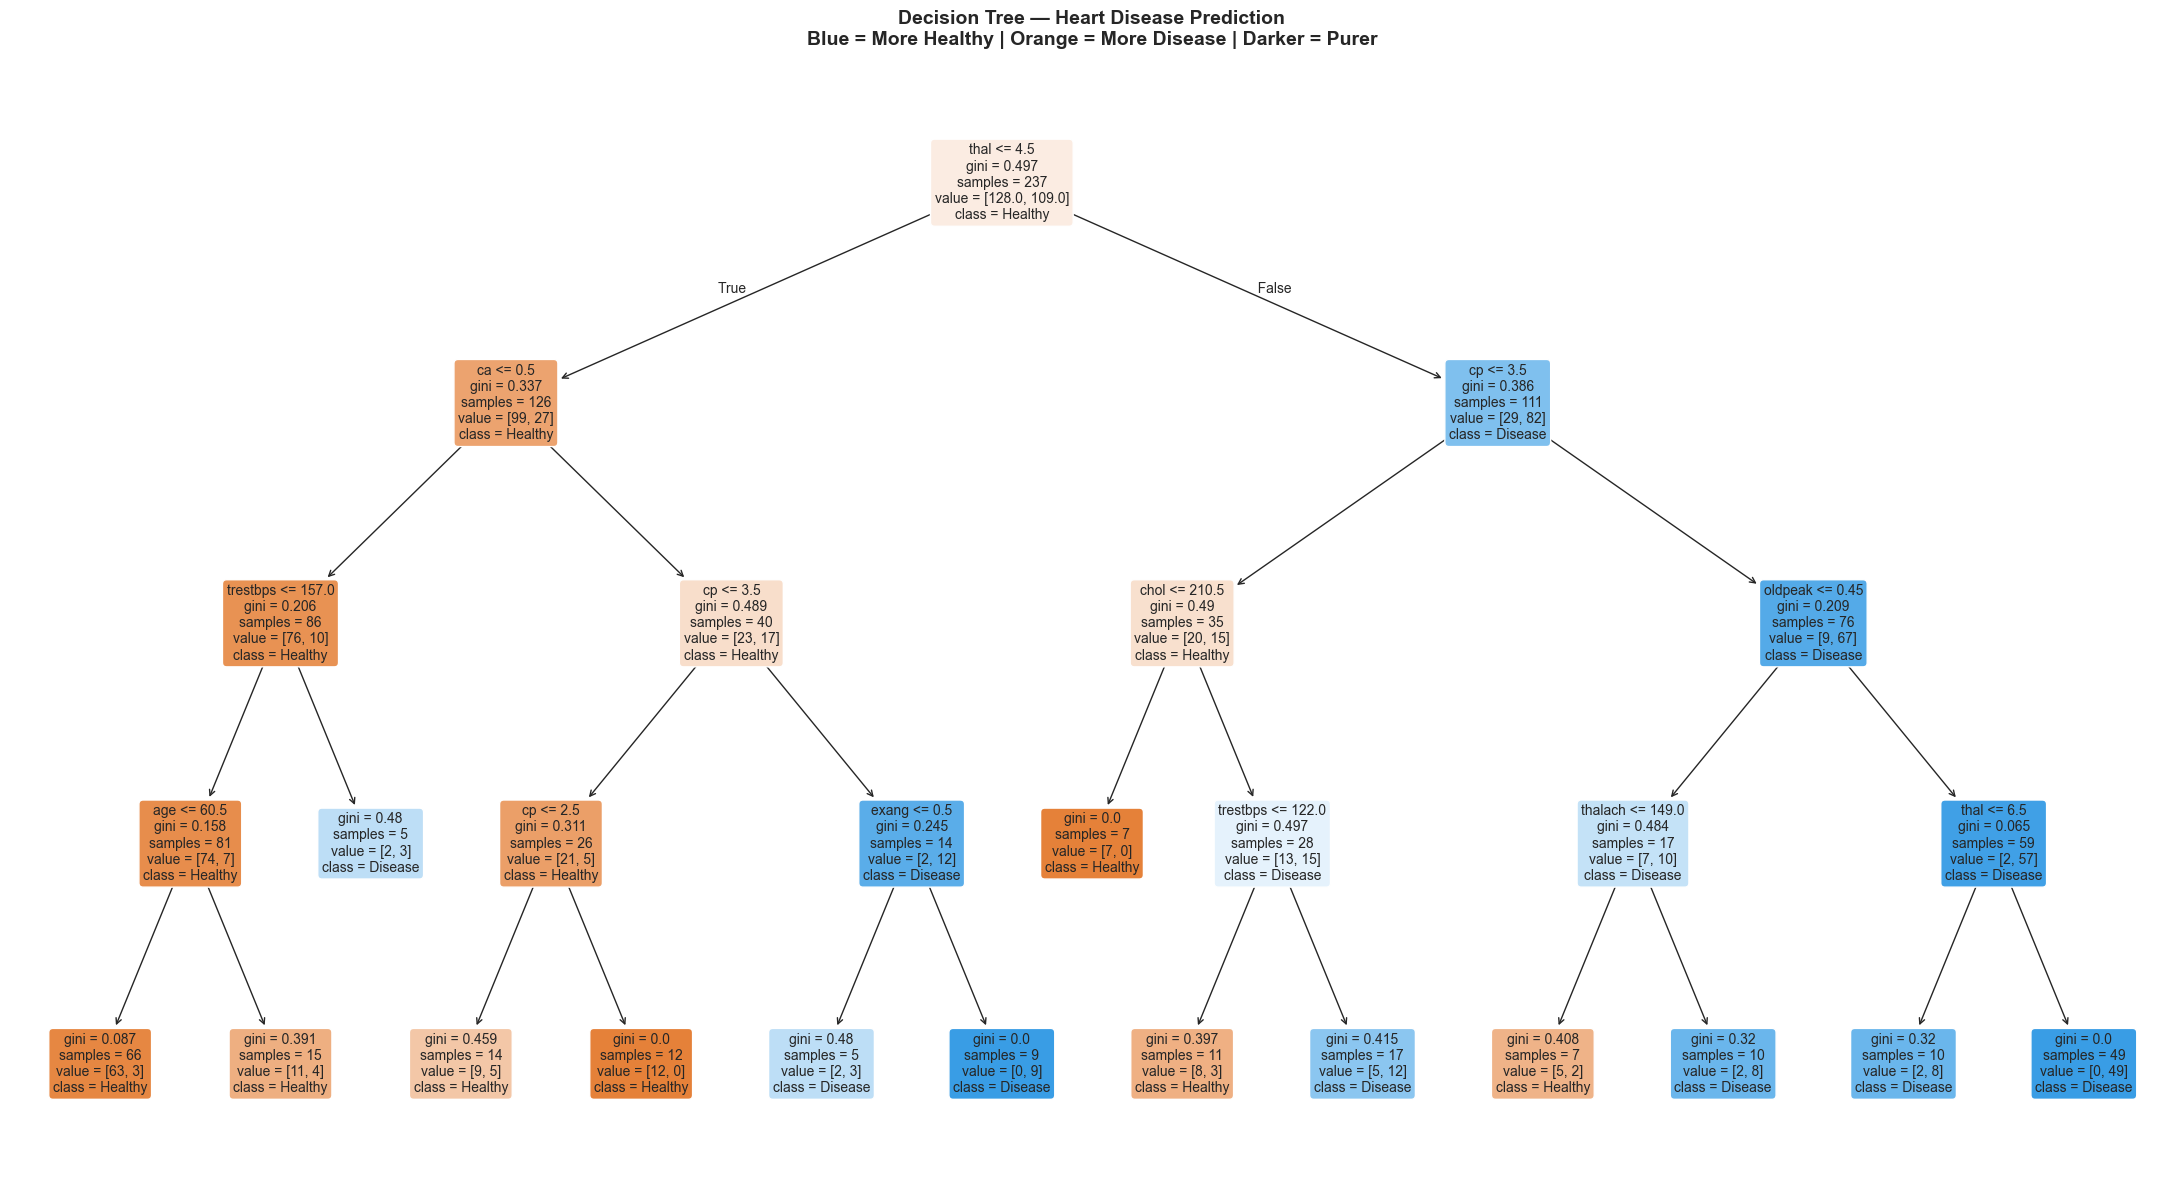


Can you trace the path from root to a leaf?
   Try: "What happens to a 63-year-old with chest pain?"


In [17]:
# VISUALIZE THE DECISION TREE
# This is the most powerful visualization — every rule is readable!

fig, ax = plt.subplots(figsize=(22, 12))

plot_tree(
    dt_best,
    feature_names=list(X.columns),
    class_names=['Healthy', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False
)

ax.set_title(
    'Decision Tree — Heart Disease Prediction\n'
    'Blue = More Healthy | Orange = More Disease | Darker = Purer',
    fontsize=14, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('decision_tree_viz.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nCan you trace the path from root to a leaf?')
print('   Try: "What happens to a 63-year-old with chest pain?"')

In [ ]:
# Print human-readable rules
# A doctor can read and verify every single rule!

print('📋 Decision Tree Rules — readable by a doctor, lawyer, or judge!')
print('='*65)
rules = export_text(dt_best, feature_names=list(X.columns))
print(rules[:2000])
print('\n💡 THIS is why Decision Trees are used in medical and legal applications!')
print('   Every decision is traceable, explainable, auditable.')

---
##  STEP 7 — Random Forest: The Power of Many Trees

**Remember the 100 doctors analogy?**
- Each doctor sees DIFFERENT patient records (bootstrapping)
- Each considers DIFFERENT symptoms (max_features)
- They VOTE together → errors cancel out → better accuracy!

 **Prediction question:** Will Random Forest beat our Decision Tree? By how much?

In [18]:
print(' Training Random Forest (100 trees)...')
print('='*50)

rf = RandomForestClassifier(
    n_estimators=100,       # 100 trees in the forest
    max_depth=6,            # Each tree limited to depth 6
    max_features='sqrt',    # Each split: sqrt(13) ≈ 3-4 features considered
    min_samples_split=5,
    oob_score=True,         # Free validation using out-of-bag samples!
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)
rf.fit(X_train, y_train)

rf_train = accuracy_score(y_train, rf.predict(X_train))
rf_test  = accuracy_score(y_test,  rf.predict(X_test))

print(f'  Train accuracy:  {rf_train:.1%}')
print(f'  Test accuracy:   {rf_test:.1%}')
print(f'  OOB score:       {rf.oob_score_:.1%}  ← FREE validation, no extra data!')
print()
print('Head-to-head comparison:')
print(f'  Decision Tree test accuracy: {dt_test:.1%}')
print(f'  Random Forest test accuracy: {rf_test:.1%}')
print(f'  Improvement: +{(rf_test - dt_test)*100:.1f} percentage points')

 Training Random Forest (100 trees)...
  Train accuracy:  95.4%
  Test accuracy:   81.7%
  OOB score:       81.0%  ← FREE validation, no extra data!

Head-to-head comparison:
  Decision Tree test accuracy: 80.0%
  Random Forest test accuracy: 81.7%
  Improvement: +1.7 percentage points


In [19]:
# Full classification report
print('Detailed Classification Report — Random Forest')
print('='*55)
print(classification_report(
    y_test,
    rf.predict(X_test),
    target_names=['Healthy (0)', 'Disease (1)']
))
print('\nKEY TERMS:')
print('  Precision = When model says "Disease", how often is it right?')
print('  Recall    = Of all actual Disease cases, how many did we catch?')
print('  In medicine: HIGH RECALL is critical — missing a case can be fatal!')

Detailed Classification Report — Random Forest
              precision    recall  f1-score   support

 Healthy (0)       0.80      0.88      0.84        32
 Disease (1)       0.84      0.75      0.79        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60


KEY TERMS:
  Precision = When model says "Disease", how often is it right?
  Recall    = Of all actual Disease cases, how many did we catch?
  In medicine: HIGH RECALL is critical — missing a case can be fatal!


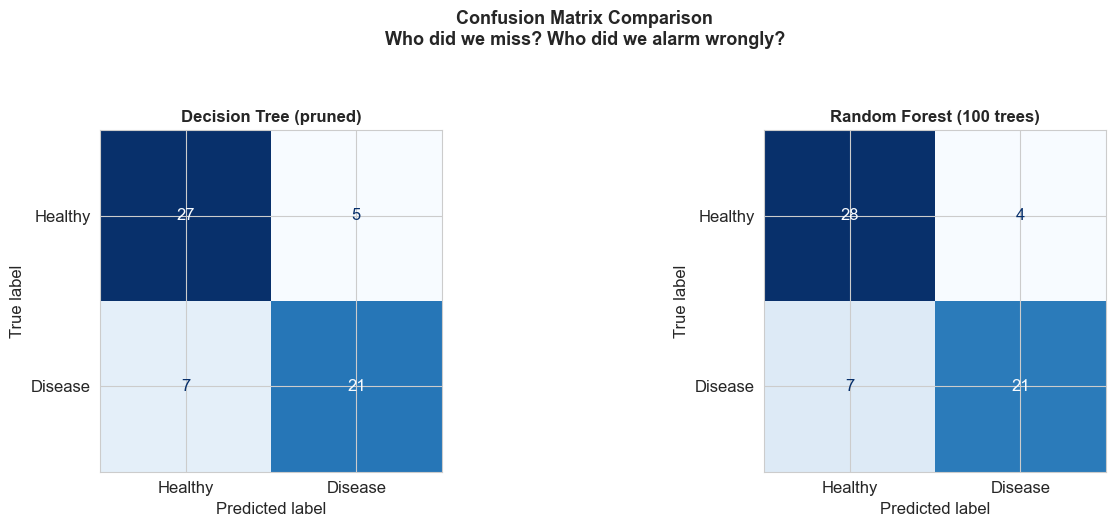


Random Forest breakdown:
   True Positives  (correctly caught disease):  21
   True Negatives  (correctly said healthy):    28
   False Positives (false alarm — said disease, was healthy): 4
   False Negatives (MISSED disease — said healthy, was sick):  7

   In medicine, False Negatives are the most dangerous error!


In [20]:
# Confusion Matrix — understand the errors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, name in zip(
    axes,
    [dt_best, rf],
    ['Decision Tree (pruned)', 'Random Forest (100 trees)']
):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Healthy', 'Disease']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrix Comparison\nWho did we miss? Who did we alarm wrongly?',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, rf.predict(X_test)).ravel()
print(f'\nRandom Forest breakdown:')
print(f'   True Positives  (correctly caught disease):  {tp}')
print(f'   True Negatives  (correctly said healthy):    {tn}')
print(f'   False Positives (false alarm — said disease, was healthy): {fp}')
print(f'   False Negatives (MISSED disease — said healthy, was sick):  {fn}')
print(f'\n   In medicine, False Negatives are the most dangerous error!')

---
##  STEP 8 — Feature Importance: What Matters Most?

 **Question before running:** Which feature do YOU think matters most for heart disease?

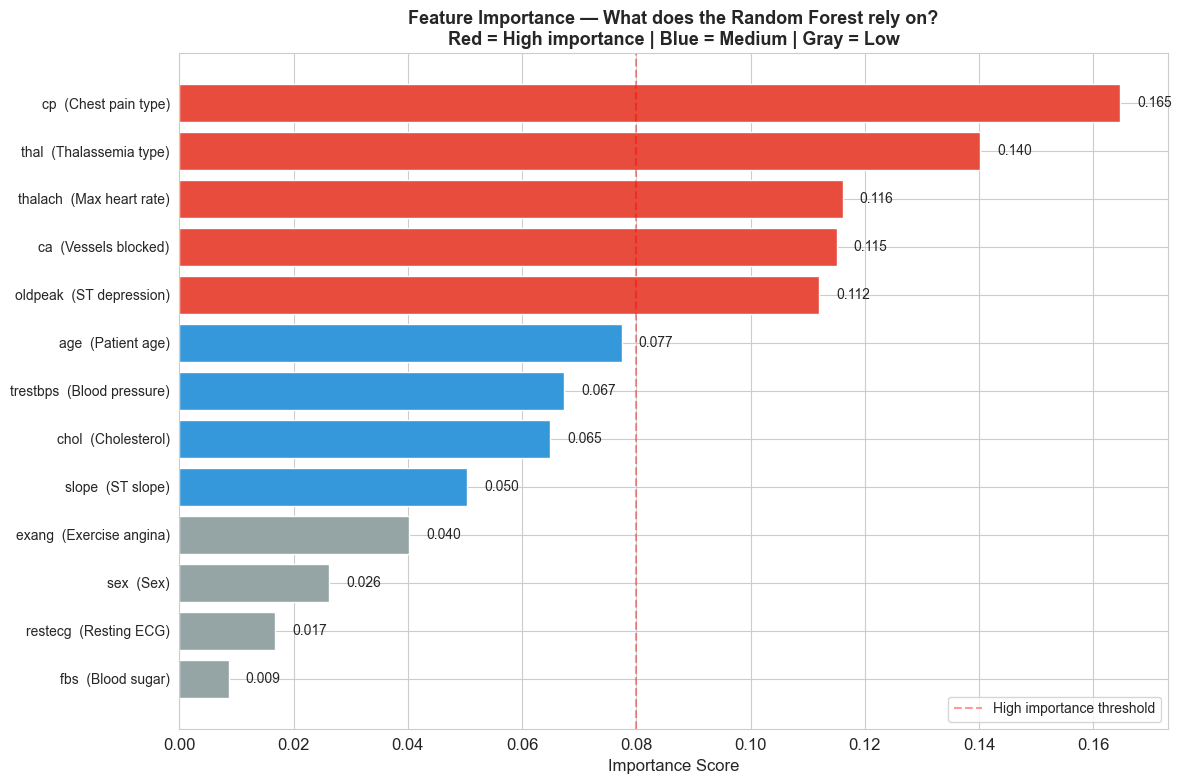


Top 3 most important features:
  cp           (Chest pain type     ) → 0.165
  thal         (Thalassemia type    ) → 0.140
  thalach      (Max heart rate      ) → 0.116

Does this align with medical knowledge? Ask a doctor!


In [21]:
# Feature Importance from Random Forest
feat_imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Feature descriptions for context
feat_descriptions = {
    'ca':       'Vessels blocked',
    'thal':     'Thalassemia type',
    'cp':       'Chest pain type',
    'thalach':  'Max heart rate',
    'oldpeak':  'ST depression',
    'age':      'Patient age',
    'slope':    'ST slope',
    'exang':    'Exercise angina',
    'chol':     'Cholesterol',
    'trestbps': 'Blood pressure',
    'sex':      'Sex',
    'restecg':  'Resting ECG',
    'fbs':      'Blood sugar'
}

colors = ['#e74c3c' if v > 0.08 else '#3498db' if v > 0.05 else '#95a5a6'
          for v in feat_imp.values]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

# Add descriptions
ax.set_yticks(range(len(feat_imp)))
ax.set_yticklabels(
    [f"{feat}  ({feat_descriptions.get(feat, '')})" for feat in feat_imp.index],
    fontsize=10
)

ax.set_title(
    'Feature Importance — What does the Random Forest rely on?\n'
    'Red = High importance | Blue = Medium | Gray = Low',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Importance Score', fontsize=12)
ax.axvline(x=0.08, color='red', linestyle='--', alpha=0.4, label='High importance threshold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

top3 = feat_imp.nlargest(3)
print('\nTop 3 most important features:')
for feat, imp in top3.items():
    print(f'  {feat:12} ({feat_descriptions[feat]:20}) → {imp:.3f}')
print('\nDoes this align with medical knowledge? Ask a doctor!')

In [22]:
# Final model comparison summary
print('FINAL MODEL COMPARISON')
print('='*65)
print(f'{"Model":<35} {"Train":>8} {"Test":>8} {"Overfit?":>12}')
print('-'*65)

models_summary = [
    ('Decision Tree (no limit — WRONG!)',   dt_unlimited, True),
    ('Decision Tree (pruned, depth=4)',     dt_best,      False),
    ('Random Forest (100 trees)',           rf,           False),
]

for name, model, _ in models_summary:
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    overfit = ' YES' if tr - te > 0.1 else ' No'
    print(f'{name:<35} {tr:>7.1%} {te:>8.1%} {overfit:>12}')

print()
print('KEY TAKEAWAYS:')
print('  1. Unlimited tree = 100% train BUT overfits badly')
print('  2. Pruned tree = honest, generalizes well, EXPLAINABLE')
print('  3. Random Forest = best accuracy, but black box')
print('  4. Choose based on YOUR need: accuracy vs interpretability')

FINAL MODEL COMPARISON
Model                                  Train     Test     Overfit?
-----------------------------------------------------------------
Decision Tree (no limit — WRONG!)    100.0%    70.0%          YES
Decision Tree (pruned, depth=4)       87.3%    80.0%           No
Random Forest (100 trees)             95.4%    81.7%          YES

KEY TAKEAWAYS:
  1. Unlimited tree = 100% train BUT overfits badly
  2. Pruned tree = honest, generalizes well, EXPLAINABLE
  3. Random Forest = best accuracy, but black box
  4. Choose based on YOUR need: accuracy vs interpretability


---
#  MINI PROJECT — Your Turn! (12 minutes)

### Choose your group task below and run the appropriate cells.

| Group | Task | Dataset |
|-------|------|---------|
| **Group A** | The Optimizers — find best hyperparameters | Pima Diabetes |
| **Group B** | The Explainers — explain model to a doctor | Breast Cancer |
| **Group C** | The Critics — find when DT beats RF | Heart Disease |

---

##  GROUP A — The Optimizers
**Task:** Find the best hyperparameters for the Pima Diabetes dataset

In [ ]:
# GROUP A — THE OPTIMIZERS
# Dataset: Pima Indians Diabetes
# Goal: Find best max_depth and n_estimators

# Load dataset
diabetes_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
diabetes_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                 'Insulin','BMI','DiabetesPedigree','Age','Outcome']

try:
    df_d = pd.read_csv(diabetes_url, names=diabetes_cols)
except:
    from sklearn.datasets import make_classification
    X_d, y_d = make_classification(n_samples=768, n_features=8, random_state=42)
    df_d = pd.DataFrame(X_d, columns=diabetes_cols[:-1])
    df_d['Outcome'] = y_d

X_d = df_d.drop('Outcome', axis=1)
y_d = df_d['Outcome']
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42
)

print('🩺 Pima Diabetes Dataset loaded!')
print(f'   {len(df_d)} patients, {len(diabetes_cols)-1} features')
print(f'   Diabetic: {y_d.sum()} | Non-diabetic: {(y_d==0).sum()}')
print()

#  YOUR TASK: Try different max_depth values (3, 5, 7, 10)
# Fill in the values below and run the cell!

depths_to_try = [3, 5, 7, 10]       # ← CHANGE THESE!
n_trees_to_try = [50, 100, 200]      # ← CHANGE THESE!

print(' Testing Decision Tree depths:')
print(f'{"Depth":>8} | {"Train":>8} | {"Test":>8} | Best?')
print('-'*40)

best_d_acc = 0
best_d_depth = 0

for d in depths_to_try:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_d.fit(X_d_train, y_d_train)
    tr = accuracy_score(y_d_train, dt_d.predict(X_d_train))
    te = accuracy_score(y_d_test,  dt_d.predict(X_d_test))
    is_best = te > best_d_acc
    if is_best:
        best_d_acc = te
        best_d_depth = d
    print(f'{d:>8} | {tr:>7.1%} | {te:>7.1%} | {" BEST" if is_best else ""}')

print(f'\n Best Decision Tree: depth={best_d_depth}, accuracy={best_d_acc:.1%}')
print()

print(' Testing Random Forest n_estimators:')
print(f'{"Trees":>8} | {"Test":>8} | Best?')
print('-'*25)

best_rf_acc = 0
best_rf_n = 0

for n in n_trees_to_try:
    rf_d = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf_d.fit(X_d_train, y_d_train)
    te = accuracy_score(y_d_test, rf_d.predict(X_d_test))
    is_best = te > best_rf_acc
    if is_best:
        best_rf_acc = te
        best_rf_n = n
    print(f'{n:>8} | {te:>7.1%} | {" BEST" if is_best else ""}')

print(f'\nBest Random Forest: {best_rf_n} trees, accuracy={best_rf_acc:.1%}')
print(f'\nPRESENT: "Our best model was ___ with ___% accuracy because ___"')

---
##  GROUP B — The Explainers
**Task:** Train a model and explain it to a doctor with NO ML background

In [ ]:
# GROUP B — THE EXPLAINERS
# Dataset: Breast Cancer (built into sklearn — zero download!)
# Goal: Visualize tree + explain in plain language

from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_c = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_c = cancer.target

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)

print(' Breast Cancer Dataset loaded!')
print(f'   {len(X_c)} samples, {X_c.shape[1]} features')
print(f'   Malignant (cancer): {(y_c==0).sum()} | Benign (no cancer): {(y_c==1).sum()}')
print()

# Train shallow tree — interpretable!
dt_c = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_c.fit(X_c_train, y_c_train)

acc = accuracy_score(y_c_test, dt_c.predict(X_c_test))
print(f' Decision Tree trained! Test accuracy: {acc:.1%}')
print()

# Visualize
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_c,
    feature_names=list(X_c.columns),
    class_names=['Malignant', 'Benign'],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title('Breast Cancer Decision Tree (max_depth=3)\nOrange=Malignant | Blue=Benign',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cancer_tree.png', dpi=100, bbox_inches='tight')
plt.show()

# Print rules
print(' Model Rules:')
print(export_text(dt_c, feature_names=list(X_c.columns))[:1500])

print()
print('  YOUR TASK: Write 3 sentences explaining this model to a doctor.')
print('   NO technical terms allowed! Use plain language.')
print()
print('   Example start: "This model looks at cell measurements...')
print('   Your explanation here:')
print()
print('   1. __________________________________________')
print('   2. __________________________________________')
print('   3. __________________________________________')
print()
print(' PRESENT: Read your 3 sentences out loud. Is it clear to a non-ML doctor?')

---
##  GROUP C — The Critics
**Task:** Find ONE scenario where Decision Tree beats Random Forest

In [ ]:
# GROUP C — THE CRITICS
# Dataset: Heart Disease (same as main demo)
# Goal: Find when Decision Tree is BETTER than Random Forest

print(' GROUP C: Finding when Decision Tree beats Random Forest')
print('='*60)

# Experiment 1: Small dataset (only 50 patients)
print('\n Experiment 1: SMALL DATASET (50 patients)')
print('   → Does RF still win with less data?')

X_small, _, y_small, _ = train_test_split(
    X, y, train_size=50, random_state=42
)

for name, model in [
    ('Decision Tree (depth=4)', DecisionTreeClassifier(max_depth=4, random_state=42)),
    ('Random Forest (100 trees)', RandomForestClassifier(n_estimators=100, random_state=42))
]:
    cv = cross_val_score(model, X_small, y_small, cv=5, scoring='accuracy')
    print(f'  {name:<30}: {cv.mean():.1%} ± {cv.std():.1%}')

# Experiment 2: Interpretability requirement
print()
print(' Experiment 2: INTERPRETABILITY REQUIREMENT')
print('   → When a doctor needs to EXPLAIN the decision...')
dt_rules = export_text(dt_best, feature_names=list(X.columns))
rule_count = dt_rules.count('|---')
print(f'  Decision Tree: {rule_count} readable rules → EXPLAINABLE ✅')
print(f'  Random Forest: 100 trees × {dt_best.get_n_leaves()} leaves = {100 * dt_best.get_n_leaves():,} decision paths → BLACK BOX ❌')

# Experiment 3: Training time
print()
print(' Experiment 3: SPEED (training time)')
import time
for name, model in [
    ('Decision Tree', DecisionTreeClassifier(max_depth=4, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42))
]:
    start = time.time()
    for _ in range(100): model.fit(X_train, y_train)
    elapsed = (time.time() - start) / 100 * 1000
    print(f'  {name:<20}: {elapsed:.2f} ms average training time')

print()
print(' DISCUSS WITH YOUR GROUP:')
print('  Q1: In which of these experiments did DT beat RF?')
print('  Q2: Look at the confusion matrix — how many patients were misdiagnosed?')
print('  Q3: What is the REAL cost of a False Negative in heart disease?')
print()
print(' PRESENT: "Decision Tree beats Random Forest when ___ because ___"')

---
##  STEP 9 — Key Takeaways

Run this final cell to see the complete summary.

In [23]:
print(' SESSION SUMMARY — Decision Trees & Random Forests')
print('='*60)
print()
print('1️⃣  DECISION TREE')
print('    Interpretable — every rule is readable')
print('    Fast to train')
print('    Overfits without pruning')
print('    Fix: max_depth, min_samples_split, min_samples_leaf')
print()
print('2️⃣  RANDOM FOREST')
print('    Higher accuracy')
print('    Robust to overfitting')
print('    OOB score = free validation!')
print('    Black box — harder to explain')
print('    Tune: n_estimators, max_depth, max_features')
print()
print('3️⃣  OUR RESULTS ON HEART DISEASE DATA')
print(f'   Decision Tree (pruned): {dt_test:.1%} test accuracy')
print(f'   Random Forest:          {rf_test:.1%} test accuracy')
print(f'   Best feature: {pd.Series(rf.feature_importances_, index=X.columns).idxmax()}')
print()
print('4️⃣  WHEN TO USE WHICH?')
print('   Decision Tree → Medical reports, legal decisions, bank loans')
print('   Random Forest → Fraud detection, recommendations, production ML')
print()
print('5️⃣  NEXT STEPS')
print('   → Try XGBoost/LightGBM — the next evolution of Random Forest')
print('   → Learn SHAP values — make Random Forest explainable')
print('   → Apply to YOUR domain: finance, sports, NLP, images')
print()
print('='*60)
print('You built a real ML model that could help doctors save lives!')
print('The same principles apply to any classification problem.')

 SESSION SUMMARY — Decision Trees & Random Forests

1️⃣  DECISION TREE
    Interpretable — every rule is readable
    Fast to train
    Overfits without pruning
    Fix: max_depth, min_samples_split, min_samples_leaf

2️⃣  RANDOM FOREST
    Higher accuracy
    Robust to overfitting
    OOB score = free validation!
    Black box — harder to explain
    Tune: n_estimators, max_depth, max_features

3️⃣  OUR RESULTS ON HEART DISEASE DATA
   Decision Tree (pruned): 80.0% test accuracy
   Random Forest:          81.7% test accuracy
   Best feature: cp

4️⃣  WHEN TO USE WHICH?
   Decision Tree → Medical reports, legal decisions, bank loans
   Random Forest → Fraud detection, recommendations, production ML

5️⃣  NEXT STEPS
   → Try XGBoost/LightGBM — the next evolution of Random Forest
   → Learn SHAP values — make Random Forest explainable
   → Apply to YOUR domain: finance, sports, NLP, images

You built a real ML model that could help doctors save lives!
The same principles apply to any cla